Transfer learning od modelot so novi podatoci na stari podatoci


In [3]:
import pandas as pd
import glob
import os, random
import tensorflow as tf
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
#vcituvanje na modelot novi_model_version2.ipynb za da go iskoristime za transfer learning
MODEL_PATH = r"D:\EMTEQ\novi\chewing_model_right.keras"
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,389 (1.86 MB)

 Trainable params: 162,497 (634.75 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 324,996 (1.24 MB)

In [5]:
DATA_DIR = r"D:\EMTEQ\modeli\za_transfer_stari"
OLD_PATH = os.path.join(DATA_DIR, "old_merged_filtered.csv")

old_raw = pd.read_csv(OLD_PATH)

label_col   = "Annotations"
subject_col = "subject"

# za da bidat isti i da moze da se upotrebi TL, inaku znaeme deka se od senzori od leva str
RENAME_MAP = {
    "Accelerometer/Raw.X": "Accelerometer X",
    "Accelerometer/Raw.Y": "Accelerometer Y",

    "Gyroscope/Raw.X": "Gyroscope X",
    "Gyroscope/Raw.Y": "Gyroscope Y",

    "RotationVector/Raw.X": "Rotation Vector X",
    "RotationVector/Raw.Y": "Rotation Vector Y",

    "Nav/Raw.X[LeftTemple]": "Navigation Right Temple X",
    "Nav/Raw.Y[LeftTemple]": "Navigation Right Temple Y",
    "Prox/Raw[LeftTemple]": "Proximity Right Temple",
    "Nav/IQ[LeftTemple]": "Navigation Right Temple IQ",
    "Nav/Shutter[LeftTemple]": "Navigation Right Temple Shutter",
    "Nav/FrameAvg[LeftTemple]": "Navigation Right Temple Frame Avg",
}

FEATURE_COLS = [
    "Accelerometer X",
    "Accelerometer Y",
    "Gyroscope X",
    "Gyroscope Y",
    "Rotation Vector X",
    "Rotation Vector Y",
    "Navigation Right Temple X",
    "Navigation Right Temple Y",
    "Proximity Right Temple",
    "Navigation Right Temple IQ",
    "Navigation Right Temple Shutter",
    "Navigation Right Temple Frame Avg",
]

print("Loaded old_raw shape:", old_raw.shape)
print(old_raw.columns.tolist())



Loaded old_raw shape: (803306, 14)
['Accelerometer X', 'Accelerometer Y', 'Gyroscope X', 'Gyroscope Y', 'Rotation Vector X', 'Rotation Vector Y', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Navigation Right Temple IQ', 'Navigation Right Temple Shutter', 'Navigation Right Temple Frame Avg', 'Annotations', 'subject']


In [6]:
#proverka dali se napraveni site transformacii 
needed = set(FEATURE_COLS + [label_col, subject_col])
missing = [c for c in needed if c not in old_raw.columns]
if missing:
    raise ValueError(f"Missing required columns in old data: {missing}")

In [7]:
#isti features kako i od novi_model_version2.ipynb
keep_cols = FEATURE_COLS + [label_col, subject_col]
old_clean = old_raw[keep_cols].copy()

old_clean = old_clean.dropna(subset=FEATURE_COLS + [label_col])
old_clean = old_clean.sort_values(["subject"]).reset_index(drop=True)
old_clean = old_clean[old_clean[label_col].isin([0, 1])]

print("After filtering:", old_clean.shape)
print("Label dist:\n", old_clean[label_col].value_counts())

old_clean.to_csv(OLD_PATH, index=False)
print("Saved:", OLD_PATH)

print("Total columns:", old_clean.shape[1])   # треба 14 (12+label+subject)
print("Features only:", len(FEATURE_COLS)) # 12


After filtering: (803306, 14)
Label dist:
 Annotations
1    522982
0    280324
Name: count, dtype: int64
Saved: D:\EMTEQ\modeli\za_transfer_stari\old_merged_filtered.csv
Total columns: 14
Features only: 12


In [8]:
print(old_clean.columns.tolist())


['Accelerometer X', 'Accelerometer Y', 'Gyroscope X', 'Gyroscope Y', 'Rotation Vector X', 'Rotation Vector Y', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Navigation Right Temple IQ', 'Navigation Right Temple Shutter', 'Navigation Right Temple Frame Avg', 'Annotations', 'subject']


In [9]:
model = tf.keras.models.load_model(MODEL_PATH)

### F1 freeze backbone: Train samo na Dense i Dense_1
### DENSE FINETUNING

In [ ]:
# raw arrays
X_all = old_clean[FEATURE_COLS].values.astype(np.float32)
y_all = old_clean[label_col].values.astype(np.int32)
groups = old_clean[subject_col].values

# split po subject
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X_all, y_all, groups))

X_train_raw, X_val_raw = X_all[train_idx], X_all[val_idx]
y_train_raw, y_val_raw = y_all[train_idx], y_all[val_idx]
g_train, g_val = groups[train_idx], groups[val_idx]

print("Train subjects:", sorted(set(g_train)))
print("Val subjects:", sorted(set(g_val)))

print("Raw train:", X_train_raw.shape, "Raw val:", X_val_raw.shape)

def make_windows_by_subject(X, y, subj, win=200, step=25):
    Xw, yw = [], []
    for s in np.unique(subj):
        idx = np.where(subj == s)[0]
        Xs, ys = X[idx], y[idx]
        for i in range(0, len(Xs) - win + 1, step):
            y_win = ys[i:i+win]
            label = int(np.mean(y_win) >= 0.5)
      
            Xw.append(Xs[i:i+win])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int32)

# windowing
X_train, y_train = make_windows_by_subject(X_train_raw, y_train_raw, g_train, win=200, step=25)
X_val, y_val     = make_windows_by_subject(X_val_raw,   y_val_raw,   g_val,   win=200, step=25)

print("Windows train:", X_train.shape, "labels:", np.bincount(y_train))
print("Windows val:",   X_val.shape,   "labels:", np.bincount(y_val))

# normalization 
mu = X_train.mean(axis=(0,1), keepdims=True)
sigma = X_train.std(axis=(0,1), keepdims=True) + 1e-8

X_train_z = (X_train - mu) / sigma
X_val_z   = (X_val   - mu) / sigma


Train subjects: ['BojanRadovski', 'DamjanSrebrenikovski', 'DanielaKovachovska', 'FilipSivevski', 'GoricaKovachovska', 'IlinaKovachovska', 'IvaJovanova', 'JovanaKostadinovska', 'KristijanMilosheski', 'MarkoKostov', 'MatejZlatkov', 'NikolaDimovski', 'OgnenSekuloski', 'SashkoKovachovski', 'StefanDinushev', 'StefanijaLazarovska', 'Tarekeating_processed.csv', 'TomiJovanoveating_processed.csv', 'VaskoDimitrovskieating_processed.csv', 'VladimirPetroveating_processed.csv']
Val subjects: ['AndrejPetrov', 'IvanaKiprijanovska', 'MarijaKovachovska', 'SaraKovachovska', 'VedranaPetreskaeating_processed.csv']
Raw train: (625984, 12) Raw val: (177322, 12)
Windows train: (24891, 200, 12) labels: [ 7931 16960]
Windows val: (7056, 200, 12) labels: [2144 4912]


In [11]:
#freeze
for layer in model.layers:
    layer.trainable = False

# Unfreeze samo dense и dense_1
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True

# sanity check
print("\nTrainable layers (Phase 1):")
for l in model.layers:
    if l.trainable:
        print(" -", l.name)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)


Trainable layers (Phase 1):
 - dense
 - dense_1


In [12]:
cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6),
]

hist1 = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=40,
    batch_size=256,
    callbacks=cb,
    verbose=1
)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.7993 - auc: 0.8494 - loss: 0.4957 - precision: 0.8486 - recall: 0.8585 - val_accuracy: 0.8638 - val_auc: 0.9075 - val_loss: 0.3474 - val_precision: 0.8679 - val_recall: 0.9487 - learning_rate: 1.0000e-04
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8149 - auc: 0.8554 - loss: 0.4383 - precision: 0.8398 - recall: 0.9001 - val_accuracy: 0.8648 - val_auc: 0.9119 - val_loss: 0.3351 - val_precision: 0.8615 - val_recall: 0.9601 - learning_rate: 1.0000e-04
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8208 - auc: 0.8640 - loss: 0.4186 - precision: 0.8359 - recall: 0.9170 - val_accuracy: 0.8669 - val_auc: 0.9163 - val_loss: 0.3262 - val_precision: 0.8650 - val_recall: 0.9585 - learning_rate: 1.0000e-04
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8271 - auc: 0.8723 - loss: 0.4052 - precision: 0.8392 - recall: 0.9232 - val_accuracy: 0.8716 - val_auc: 0.9200 - val_loss: 0.3

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

# default threshold 0.5 
y_prob = model.predict(X_val_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.64).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_val, y_pred, digits=4))

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Confusion matrix:
 [[1854  290]
 [ 822 4090]]
              precision    recall  f1-score   support

           0     0.6928    0.8647    0.7693      2144
           1     0.9338    0.8327    0.8803      4912

    accuracy                         0.8424      7056
   macro avg     0.8133    0.8487    0.8248      7056
weighted avg     0.8606    0.8424    0.8466      7056



In [14]:
model.save(r"D:\EMTEQ\modeli\phase1_dense_only.keras")

 The model is initially trained on newly recorded data and learns general chewing patterns. In Phase 1 of transfer learning, the backbone layers are frozen, and only the classification layers are fine-tuned on the old data, allowing the model to learn how to interpret the already extracted features in the new domain. This phase is crucial for successful adaptation. Then, by partially unfreezing the last convolutional block, the model further adjusts, after which a final evaluation is performed on a separate test set.

### F2: Partial unfreeze
### UNFREEZE conv1d_2

In [15]:
# se freeze 
for layer in model.layers:
    layer.trainable = False

# F1 ni ostanuva za train dense i dense_1
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True

# unfreeze conv1d_2 (posledniot conv sloj)
for layer in model.layers:
    if layer.name == "conv1d_2":
        layer.trainable = True

print("\nTrainable layers (Phase 2):")
for l in model.layers:
    if l.trainable:
        print(" -", l.name)



Trainable layers (Phase 2):
 - conv1d_2
 - dense
 - dense_1


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # мал LR
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)


In [17]:
cb2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6),
]

hist2 = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=40,
    batch_size=256,
    callbacks=cb2,
    verbose=1
)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.8693 - auc: 0.9194 - loss: 0.3279 - precision: 0.8847 - recall: 0.9292 - val_accuracy: 0.8741 - val_auc: 0.9275 - val_loss: 0.3077 - val_precision: 0.9150 - val_recall: 0.9031 - learning_rate: 1.0000e-05
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - accuracy: 0.8690 - auc: 0.9184 - loss: 0.3284 - precision: 0.8847 - recall: 0.9288 - val_accuracy: 0.8746 - val_auc: 0.9281 - val_loss: 0.3066 - val_precision: 0.9156 - val_recall: 0.9031 - learning_rate: 1.0000e-05
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.8710 - auc: 0.9215 - loss: 0.3225 - precision: 0.8870 - recall: 0.9291 - val_accuracy: 0.8756 - val_auc: 0.9285 - val_loss: 0.3056 - val_precision: 0.9160 - val_recall: 0.9041 - learning_rate: 1.0000e-05
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.8724 - auc: 0.9224 - loss: 0.3207 - precision: 0.8872 - recall: 0.9311 - val_accuracy: 0.8743 - val_auc: 0.9287 - val_lo

In [18]:
y_prob = model.predict(X_val_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix (Phase 2):\n", cm)
print(classification_report(y_val, y_pred, digits=4))


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step
Confusion Matrix (Phase 2):
 [[1764  380]
 [ 529 4383]]
              precision    recall  f1-score   support

           0     0.7693    0.8228    0.7951      2144
           1     0.9202    0.8923    0.9060      4912

    accuracy                         0.8712      7056
   macro avg     0.8448    0.8575    0.8506      7056
weighted avg     0.8744    0.8712    0.8723      7056



In [19]:
model.save(r"D:\EMTEQ\modeli\phase2_unfreeze_conv1d2.keras")

cisto za proba i sporedba

### UNFREEZE conv1d_1 i conv1d_2

In [20]:
# se freeze 
for layer in model.layers:
    layer.trainable = False

# F1 ni ostanuva za train dense i dense_1
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True

# unfreeze conv1d_2 (posledniot conv sloj)
for layer in model.layers:
    if layer.name in ["conv1d_1", "conv1d_2"]:
        layer.trainable = True
    if "batch_normalization" in layer.name:
        layer.trainable = False # BatchNorm sloevite ne gi trenirame frozen


print("\nTrainable layers (Phase 2):")
for l in model.layers:
    if l.trainable:
        print(" -", l.name)



Trainable layers (Phase 2):
 - conv1d_1
 - conv1d_2
 - dense
 - dense_1


In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)


In [22]:
cb3 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6),
]

hist3 = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=40,
    batch_size=256,
    callbacks=cb2,
    verbose=1
)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 48s 354ms/step - accuracy: 0.8785 - auc: 0.9285 - loss: 0.3056 - precision: 0.8934 - recall: 0.9331 - val_accuracy: 0.8679 - val_auc: 0.9286 - val_loss: 0.3088 - val_precision: 0.9193 - val_recall: 0.8882 - learning_rate: 1.0000e-05
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.8811 - auc: 0.9327 - loss: 0.2975 - precision: 0.8938 - recall: 0.9368 - val_accuracy: 0.8656 - val_auc: 0.9277 - val_loss: 0.3113 - val_precision: 0.9180 - val_recall: 0.8862 - learning_rate: 1.0000e-05
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.8808 - auc: 0.9320 - loss: 0.2983 - precision: 0.8938 - recall: 0.9363 - val_accuracy: 0.8622 - val_auc: 0.9272 - val_loss: 0.3133 - val_precision: 0.9168 - val_recall: 0.8821 - learning_rate: 1.0000e-05
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.8831 - auc: 0.9335 - loss: 0.2950 - precision: 0.8950 - recall: 0.9386 - val_accuracy: 0.8614 - val_auc: 0.9269 - val_lo

In [23]:
y_prob = model.predict(X_val_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix (Phase 2):\n", cm)
print(classification_report(y_val, y_pred, digits=4))



28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
Confusion Matrix (Phase 2):
 [[1761  383]
 [ 549 4363]]
              precision    recall  f1-score   support

           0     0.7623    0.8214    0.7907      2144
           1     0.9193    0.8882    0.9035      4912

    accuracy                         0.8679      7056
   macro avg     0.8408    0.8548    0.8471      7056
weighted avg     0.8716    0.8679    0.8692      7056



In [24]:
model.save(r"D:\EMTEQ\modeli\phase2b_unfreeze_conv1d1_conv1d2.keras")

In [25]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

def eval_model(model_path, X_val_z, y_val, thr=0.5):
    m = tf.keras.models.load_model(model_path)

    y_prob = m.predict(X_val_z, batch_size=256).ravel()
    y_pred = (y_prob >= thr).astype(int)

    cm = confusion_matrix(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_prob)

    return {
        "model": model_path.split("\\")[-1],
        "threshold": thr,
        "f1": f1,
        "precision": prec,
        "recall": rec,
        "auc": auc,
        "tn": int(cm[0,0]),
        "fp": int(cm[0,1]),
        "fn": int(cm[1,0]),
        "tp": int(cm[1,1]),
    }

paths = [
    r"D:\EMTEQ\modeli\phase1_dense_only.keras",
    r"D:\EMTEQ\modeli\phase2_unfreeze_conv1d2.keras",
    r"D:\EMTEQ\modeli\phase2b_unfreeze_conv1d1_conv1d2.keras",
]

results = [eval_model(p, X_val_z, y_val, thr=0.5) for p in paths]
results


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step


[{'model': 'phase1_dense_only.keras',
  'threshold': 0.5,
  'f1': 0.9083076923076923,
  'precision': 0.9152542372881356,
  'recall': 0.9014657980456026,
  'auc': np.float64(0.9267832129053429),
  'tn': 1734,
  'fp': 410,
  'fn': 484,
  'tp': 4428},
 {'model': 'phase2_unfreeze_conv1d2.keras',
  'threshold': 0.5,
  'f1': 0.906046511627907,
  'precision': 0.9202183497795507,
  'recall': 0.8923045602605864,
  'auc': np.float64(0.9297975051199621),
  'tn': 1764,
  'fp': 380,
  'fn': 529,
  'tp': 4383},
 {'model': 'phase2b_unfreeze_conv1d1_conv1d2.keras',
  'threshold': 0.5,
  'f1': 0.9034996893766826,
  'precision': 0.9193004635482511,
  'recall': 0.8882328990228013,
  'auc': np.float64(0.928683258179785),
  'tn': 1761,
  'fp': 383,
  'fn': 549,
  'tp': 4363}]

In [26]:
df_cmp = pd.DataFrame(results).sort_values(by="f1", ascending=False)
df_cmp

,model,threshold,f1,precision,recall,auc,tn,fp,fn,tp
0,phase1_dense_only.keras,0.5,0.908308,0.915254,0.901466,0.926783,1734,410,484,4428
1,phase2_unfreeze_conv1d2.keras,0.5,0.906047,0.920218,0.892305,0.929798,1764,380,529,4383
2,phase2b_unfreeze_conv1d1_conv1d2.keras,0.5,0.903500,0.919300,0.888233,0.928683,1761,383,549,4363


In [27]:
for thr in [0.5, 0.45, 0.4]:
    y_pred = (y_prob >= thr).astype(int)
    print(thr, "F1:", f1_score(y_val, y_pred), "CM:", confusion_matrix(y_val, y_pred).tolist())


0.5 F1: 0.9034996893766826 CM: [[1761, 383], [549, 4363]]
0.45 F1: 0.909480122324159 CM: [[1707, 437], [451, 4461]]
0.4 F1: 0.9155099577549789 CM: [[1665, 479], [361, 4551]]


znaci najdobro si e so threshold = 0.5 

## Comparison of Transfer Learning Strategies (Phase 1 vs Phase 2)

In this work, several transfer learning strategies were evaluated to adapt a model trained on newly collected Emteq data to previously recorded datasets. The baseline approach (Phase 1), in which the backbone layers were frozen and only the Dense classification layers were fine-tuned, provided stable performance with good generalization while requiring minimal training time.

In Phase 2, partial unfreezing of the backbone was applied. First, only the last convolutional layer (`conv1d_2`) was unfrozen. This configuration resulted in a clear improvement in recall and F1-score for the *chewing* class, significantly reducing the number of false negatives, which is critical for chewing detection tasks. At the same time, training time and computational cost remained reasonable, making this approach an effective compromise between performance and efficiency.

An additional experiment was conducted by unfreezing multiple convolutional layers (`conv1d_1` and `conv1d_2`). Although this strategy yielded marginal improvements in some metrics, such as accuracy and F1-score, the gains were relatively small compared to the substantial increase in training time and computational resources. This indicates that further fine-tuning of deeper convolutional layers is unnecessary, as the two datasets are already highly compatible at the level of low- and mid-level sensor features.

Given that a primary objective of transfer learning is to reduce training time and resource consumption while maintaining high performance, the best trade-off was achieved by unfreezing only the last convolutional layer. Therefore, the model obtained in Phase 2 (`phase2_unfreeze_conv1d2.keras`) is selected as the final transfer learning model for subsequent evaluation and deployment.


In [28]:
tl_model_path = r"D:\EMTEQ\modeli\phase2_unfreeze_conv1d2.keras"
model = tf.keras.models.load_model(tl_model_path)

In [29]:
from sklearn.model_selection import GroupShuffleSplit

# X_all, y_all, groups веќе ги имаш
gss1 = GroupShuffleSplit(test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_all, y_all, groups))

X_test_raw = X_all[test_idx]
y_test_raw = y_all[test_idx]
g_test     = groups[test_idx]

print("TEST subjects:", sorted(set(g_test)))


TEST subjects: ['AndrejPetrov', 'IvanaKiprijanovska', 'MarijaKovachovska', 'SaraKovachovska', 'VedranaPetreskaeating_processed.csv']


In [30]:
WIN  = 150
STEP = 25

X_test, y_test = make_windows_by_subject(
    X_test_raw, y_test_raw, g_test,
    win=WIN, step=STEP, 
)

print("Test windows:", X_test.shape)
print("Test labels:", np.bincount(y_test), "ratio:", y_test.mean())


Test windows: (7066, 150, 12)
Test labels: [2196 4870] ratio: 0.689215963770167


In [31]:
X_test_z = (X_test - mu) / sigma


In [32]:
y_prob = model.predict(X_test_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.5).astype(int)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


In [33]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score,
    accuracy_score
)

cm = confusion_matrix(y_test, y_pred)

print("=== FINAL TEST RESULTS ===")
print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))


=== FINAL TEST RESULTS ===
Confusion Matrix:
 [[1793  403]
 [ 536 4334]]
Accuracy: 0.867110104726861
F1-score: 0.9022587696471323
AUC: 0.9250945343970557

Classification report:

              precision    recall  f1-score   support

           0     0.7699    0.8165    0.7925      2196
           1     0.9149    0.8899    0.9023      4870

    accuracy                         0.8671      7066
   macro avg     0.8424    0.8532    0.8474      7066
weighted avg     0.8698    0.8671    0.8681      7066



In [34]:
#proverka na threshold
for thr in [0.5, 0.45, 0.4]:
    yp = (y_prob >= thr).astype(int)
    print(
        "thr=", thr,
        "F1=", f1_score(y_test, yp),
        "Acc=", accuracy_score(y_test, yp),
        "CM=", confusion_matrix(y_test, yp).tolist()
    )


thr= 0.5 F1= 0.9022587696471323 Acc= 0.867110104726861 CM= [[1793, 403], [536, 4334]]
thr= 0.45 F1= 0.9070173636083427 Acc= 0.871921879422587 CM= [[1747, 449], [456, 4414]]
thr= 0.4 F1= 0.9109352809900588 Acc= 0.8757429946221341 CM= [[1698, 498], [380, 4490]]


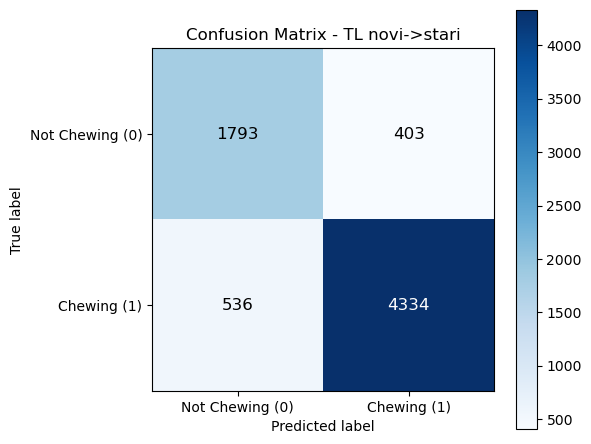

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - TL novi->stari")

classes = ["Not Chewing (0)", "Chewing (1)"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=12)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
